# Notebook de Replicação da Previsão de Atraso à Chegada (Duração), versão A

**Paper:** Biswas et al. (2024). *Spatio-Temporal Feature Engineering and Selection-Based Flight Arrival Delay Prediction Using Deep Feedforward Regression Network.* Electronics 13(24), 4910. DOI: 10.3390/electronics13244910

**Dataset:** Flight Delay and Cancellation Data (2019–2023) v2 - Kaggle  
https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-data-2019-2023-v2

**Target:** `ARR_DELAY` - atraso à chegada (minutos)

### Resultados esperados (paper, test set)
| Modelo | RMSE | MAE | R²% |
|---|---|---|---|
| HGBR | 7.923 | 3.886 | 98.118 |
| LR | 6.661 | 4.645 | 98.670 |
| Decision Tree | 6.661 | 4.645 | 98.670 |
| GBR | 6.272 | 4.203 | 98.821 |
| LightGBM | 4.643 | 2.559 | 99.354 |
| CNN | 4.519 | 3.168 | 99.388 |
| XGBoost | 5.811 | 2.179 | 98.988 |
| MLP | 3.504 | 2.309 | 99.632 |
| CatBoost | 3.884 | 1.683 | 99.548 |
| Random Forest | 3.892 | 1.371 | 99.546 |
| LSTM | 2.057 | 1.255 | 99.873 |
| **DFFRN** | **1.672** | **1.049** | **99.916** |

## 0. Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, BaggingRegressor,
    GradientBoostingRegressor, AdaBoostRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans

# Boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Airport data
import airportsdata

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

TensorFlow: 2.20.0
NumPy: 2.3.4
Pandas: 2.3.3


## 1. Carregamento do Dataset

**Instruções:**  
1. Descarregar o CSV de 2M linhas (~409MB) do Kaggle:  
   https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-data-2019-2023-v2  
2. Colocar o ficheiro na mesma pasta que este notebook  
3. Ajustar `CSV_PATH` se necessário

O paper filtra apenas dados de **2023** e dos **5 estados**: CA, TX, FL, NY, GA  
→ resultado esperado após filtragem: ~186.506 voos

In [2]:
CSV_PATH = "flights_sample_2m.csv"   # ficheiro de 2M linhas (~409 MB)

TARGET_STATES = ['CA', 'TX', 'FL', 'NY', 'GA']   # os 5 estados do paper
TARGET_STATES_FULL = {'California', 'Texas', 'Florida', 'New York', 'Georgia'}
TARGET_YEAR   = 2023

print("A carregar dataset...")
t0 = time.time()

df_raw = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Shape original: {df_raw.shape}")
print(f"Colunas ({len(df_raw.columns)}): {list(df_raw.columns)}")
print(f"Tempo de carregamento: {time.time()-t0:.1f}s")

A carregar dataset...
Shape original: (2000000, 32)
Colunas (32): ['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']
Tempo de carregamento: 9.0s


In [3]:
# Filtrar ano 2023 e 5 estados (ORIGIN ou DEST)
# CSV v2 não tem coluna de estado - derivar via airportsdata

df_raw['FL_DATE'] = pd.to_datetime(df_raw['FL_DATE'], errors='coerce')

df = df_raw[df_raw['FL_DATE'].dt.year == TARGET_YEAR].copy()
print(f"Após filtro 2023: {len(df):,} registos")

airports_db = airportsdata.load('IATA')
df['ORIGIN_STATE'] = df['ORIGIN'].map(lambda x: airports_db.get(str(x), {}).get('subd', None))
df['DEST_STATE']   = df['DEST'].map(lambda x:   airports_db.get(str(x), {}).get('subd', None))

df = df[
    df['ORIGIN_STATE'].isin(TARGET_STATES_FULL) |
    df['DEST_STATE'].isin(TARGET_STATES_FULL)
].copy()

print(f"Após filtro estados (CA/TX/FL/NY/GA): {len(df):,} registos")
print(f"Esperado pelo paper: ~186.506")

Após filtro 2023: 310,303 registos
Após filtro estados (CA/TX/FL/NY/GA): 199,825 registos
Esperado pelo paper: ~186.506


## 2. Limpeza de Dados (Section 3.1)

### 2.1 Drop de Colunas Irrelevantes (Table 2 do paper)

In [4]:
# Colunas post-arrival - só disponíveis depois do voo aterrar (Table 2)
COLS_TO_DROP_TABLE2 = ['WHEELS_ON', 'TAXI_IN', 'ELAPSED_TIME', 'AIR_TIME', 'ARR_TIME']

# Drop apenas as que existem no dataset
existing_drop = [c for c in COLS_TO_DROP_TABLE2 if c in df.columns]
df.drop(columns=existing_drop, inplace=True)
print(f"Colunas dropped (post-arrival): {existing_drop}")
print(f"Shape: {df.shape}")

Colunas dropped (post-arrival): ['WHEELS_ON', 'TAXI_IN', 'ELAPSED_TIME', 'AIR_TIME', 'ARR_TIME']
Shape: (199825, 29)


### 2.2 Drop de Voos Cancelados e Desviados (Eq. 1–2)

In [5]:
# D' = D \ (C ∪ V)  - Equação 2 do paper
n_before = len(df)

cancelled_col = 'CANCELLED' if 'CANCELLED' in df.columns else None
diverted_col  = 'DIVERTED'  if 'DIVERTED'  in df.columns else None

if cancelled_col:
    n_cancelled = df[cancelled_col].sum()
    df = df[df[cancelled_col] != 1].copy()
    print(f"Cancelados removidos: {n_cancelled} (paper: 3.306)")

if diverted_col:
    n_diverted = df[diverted_col].sum()
    df = df[df[diverted_col] != 1].copy()
    print(f"Desviados removidos: {n_diverted} (paper: 549)")

print(f"Shape após drop cancelados/desviados: {df.shape}")

Cancelados removidos: 3312.0 (paper: 3.306)
Desviados removidos: 563.0 (paper: 549)
Shape após drop cancelados/desviados: (195950, 29)


### 2.3 Tratamento de Missing Values (Tables 3 & 4)

In [6]:
# Calcular % missing por coluna
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Colunas com missing values:")
print(missing_pct.to_string())

Colunas com missing values:
CANCELLATION_CODE          100.000000
DELAY_DUE_CARRIER           76.279663
DELAY_DUE_WEATHER           76.279663
DELAY_DUE_NAS               76.279663
DELAY_DUE_SECURITY          76.279663
DELAY_DUE_LATE_AIRCRAFT     76.279663


In [7]:
# Table 3: Drop colunas com >50% missing
COLS_HIGH_MISSING = [
    'CANCELLATION_CODE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'
]
# Incluir também qualquer coluna com >50% missing que exista
high_missing_auto = missing_pct[missing_pct > 50].index.tolist()
to_drop_high = list(set(COLS_HIGH_MISSING + high_missing_auto))
to_drop_high = [c for c in to_drop_high if c in df.columns]

df.drop(columns=to_drop_high, inplace=True)
print(f"Dropped (>50% missing): {to_drop_high}")

# Table 4: Drop rows com <5% missing nas colunas operacionais
COLS_NEGLIGIBLE_MISSING = ['TAXI_OUT', 'WHEELS_OFF', 'DEP_DELAY', 'DEP_TIME', 'DEST_STATE', 'CRS_ELAPSED_TIME']
existing_neg = [c for c in COLS_NEGLIGIBLE_MISSING if c in df.columns]

n_before = len(df)
df.dropna(subset=existing_neg, inplace=True)
# Também remover rows com ARR_DELAY nulo (target)
df.dropna(subset=['ARR_DELAY'], inplace=True)
print(f"Rows removidas por missing (<5%): {n_before - len(df)}")
print(f"Shape final após limpeza: {df.shape}")
print(f"Esperado pelo paper: 186.506")

Dropped (>50% missing): ['DELAY_DUE_SECURITY', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'CANCELLATION_CODE', 'DELAY_DUE_LATE_AIRCRAFT']
Rows removidas por missing (<5%): 0
Shape final após limpeza: (195950, 23)
Esperado pelo paper: 186.506


## 3. Integração de Coordenadas Geográficas (Section 3.2, Eq. 3)

In [8]:
# Carregar base de dados de aeroportos (airportsdata)
airports = airportsdata.load('IATA')  # keyed by IATA code

def get_lat(iata):
    if iata in airports:
        return airports[iata]['lat']
    return np.nan

def get_lon(iata):
    if iata in airports:
        return airports[iata]['lon']
    return np.nan

# Merge coordenadas de origem
df['ORIGIN_LAT'] = df['ORIGIN'].map(get_lat)
df['ORIGIN_LON'] = df['ORIGIN'].map(get_lon)

# Merge coordenadas de destino
df['DEST_LAT'] = df['DEST'].map(get_lat)
df['DEST_LON'] = df['DEST'].map(get_lon)

# Drop rows sem coordenadas (aeroportos desconhecidos)
n_before = len(df)
df.dropna(subset=['ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON'], inplace=True)
print(f"Rows removidas por coordenadas em falta: {n_before - len(df)}")
print(f"Shape: {df.shape}")
df[['ORIGIN', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST', 'DEST_LAT', 'DEST_LON']].head(3)

Rows removidas por coordenadas em falta: 0
Shape: (195950, 27)


,ORIGIN,ORIGIN_LAT,ORIGIN_LON,DEST,DEST_LAT,DEST_LON
7,IND,39.717306,-86.294639,JFK,40.639928,-73.778692
9,EWR,40.692481,-74.168688,FLL,26.071667,-80.149694
23,LAX,33.942496,-118.408049,RNO,39.499111,-119.768111


## 4. Análise Exploratória de Dados - EDA (Section 3.4)

### 4.1 Voos por Estado (Fig. 3)

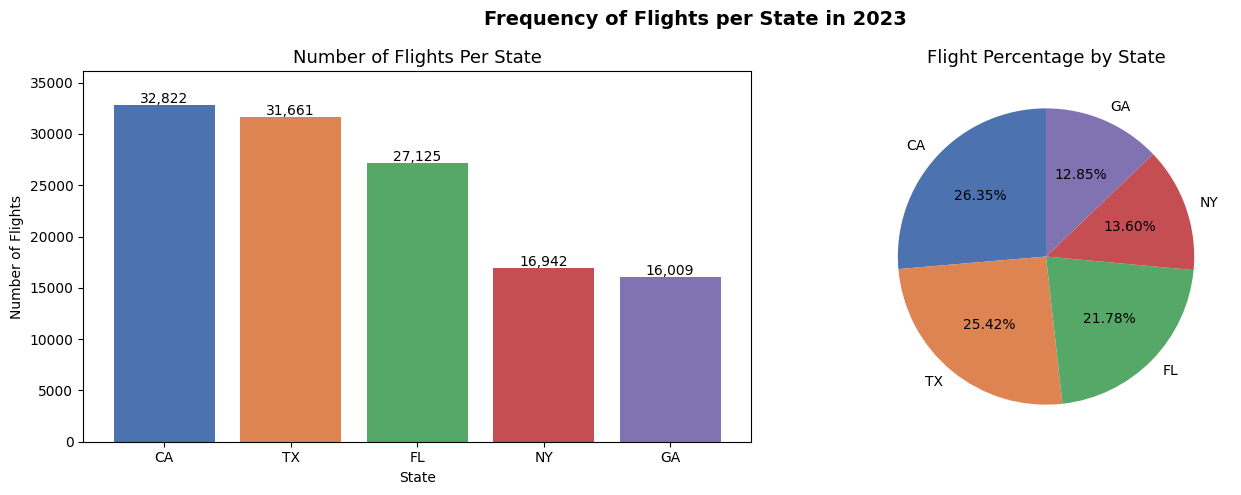


Contagens por estado:
  CA: 32,822
  TX: 31,661
  FL: 27,125
  NY: 16,942
  GA: 16,009

Esperado: CA=49255, TX=47365, FL=40754, NY=25121, GA=24011


In [9]:
STATE_ORDER = ['California', 'Texas', 'Florida', 'New York', 'Georgia']
STATE_ABBR  = {'California': 'CA', 'Texas': 'TX', 'Florida': 'FL', 'New York': 'NY', 'Georgia': 'GA'}

state_counts = df['ORIGIN_STATE'].value_counts().reindex(STATE_ORDER)
state_counts.index = state_counts.index.map(STATE_ABBR)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(state_counts.index, state_counts.values,
            color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
for i, (s, v) in enumerate(zip(state_counts.index, state_counts.values)):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
axes[0].set_title('Number of Flights Per State', fontsize=13)
axes[0].set_xlabel('State')
axes[0].set_ylabel('Number of Flights')
axes[0].set_ylim(0, state_counts.max() * 1.1)

axes[1].pie(state_counts.values, labels=state_counts.index,
            autopct='%1.2f%%', startangle=90,
            colors=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
axes[1].set_title('Flight Percentage by State', fontsize=13)

plt.suptitle('Frequency of Flights per State in 2023', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig03_flights_per_state.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nContagens por estado:")
for s, v in zip(state_counts.index, state_counts.values):
    print(f"  {s}: {v:,}")
print("\nEsperado: CA=49255, TX=47365, FL=40754, NY=25121, GA=24011")

## 5. Feature Engineering (Section 3.3)

### 5.1 Features Temporais (Section 3.3.1)

In [10]:
df = df.reset_index(drop=True)

# Garantir FL_DATE é datetime
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')

# 1. Month - captura variações sazonais
df['Month'] = df['FL_DATE'].dt.month

# 2. Day of Month
df['DayofMonth'] = df['FL_DATE'].dt.day

# 3. Weekday (0=Monday ... 6=Sunday)
df['DayofWeek'] = df['FL_DATE'].dt.dayofweek

# 4. Week of Year (ISO)
df['WeekofYear'] = df['FL_DATE'].dt.isocalendar().week.astype(int)

# 5. Quarter
df['Quarter'] = df['FL_DATE'].dt.quarter

# 6. Is Weekend - Eq. 4: Iw = 1 if w >= 5, else 0
df['IsWeekend'] = (df['DayofWeek'] >= 5).astype(int)

# 7. Hour Extraction - CRS_DEP_TIME é formato HHMM
df['CRS_DEP_TIME'] = pd.to_numeric(df['CRS_DEP_TIME'], errors='coerce')
df['DEP_HOUR'] = (df['CRS_DEP_TIME'] // 100).astype('Int64')

# 8. Minute Extraction
df['DEP_MINUTE'] = (df['CRS_DEP_TIME'] % 100).astype('Int64')

# 9. Departure Time Categorization - Eq. 5
def categorize_dep_time(t):
    if pd.isna(t) or t > 2359:
        return 'Invalid Time'
    t = int(t)
    if   t <  200: return '12am-2am'
    elif t <  400: return '2am-4am'
    elif t <  600: return '4am-6am'
    elif t <  800: return '6am-8am'
    elif t < 1000: return '8am-10am'
    elif t < 1200: return '10am-12pm'
    elif t < 1400: return '12pm-2pm'
    elif t < 1600: return '2pm-4pm'
    elif t < 1800: return '4pm-6pm'
    elif t < 2000: return '6pm-8pm'
    elif t < 2200: return '8pm-10pm'
    else:          return '10pm-12am'

df['DEP_TIME_CATEGORY'] = df['CRS_DEP_TIME'].apply(categorize_dep_time)

# 10. Night Flight Indicator - Eq. 6: N=1 if 2100<=T<=2359 or 0<=T<400
def is_night_flight(t):
    if pd.isna(t):
        return 0
    t = int(t)
    return 1 if (t >= 2100 or t < 400) else 0

df['IsNightFlight'] = df['CRS_DEP_TIME'].apply(is_night_flight)

print("Features temporais criadas:")
print(df[['Month','DayofMonth','DayofWeek','WeekofYear','Quarter',
          'IsWeekend','DEP_HOUR','DEP_MINUTE','DEP_TIME_CATEGORY','IsNightFlight']].head(3))

Features temporais criadas:
   Month  DayofMonth  DayofWeek  WeekofYear  Quarter  IsWeekend  DEP_HOUR  \
0      8          12          5          32        3          1         7   
1      1           1          6          52        1          1        14   
2      8          27          6          34        3          1        19   

   DEP_MINUTE DEP_TIME_CATEGORY  IsNightFlight  
0          45           6am-8am              0  
1           0           2pm-4pm              0  
2          13           6pm-8pm              0  


### 5.2 Previous Delay Features (Section 3.3.2)

In [11]:
# Garantir tipos numéricos
df['DEP_DELAY'] = pd.to_numeric(df['DEP_DELAY'], errors='coerce')
df['ARR_DELAY'] = pd.to_numeric(df['ARR_DELAY'], errors='coerce')

# Ordenar por data e aeroporto para calcular lags corretamente
df.sort_values(['FL_DATE', 'ORIGIN', 'DEST'], inplace=True)
df.reset_index(drop=True, inplace=True)

# 1. Previous Departure Delay - Eq. 7: Δprev = Δi-1 ∀i ∈ ORIGIN
df['Prev_DEP_DELAY'] = df.groupby('ORIGIN')['DEP_DELAY'].shift(1)

# 2. Previous Arrival Delay - Eq. 8: Aprev = Ai-1 ∀i ∈ DEST
df['Prev_ARR_DELAY'] = df.groupby('DEST')['ARR_DELAY'].shift(1)

# 3. Rolling Departure Delay (N=5) - Eq. 9: média dos últimos 5 voos do mesmo ORIGIN
df['Rolling_DEP_DELAY'] = (
    df.groupby('ORIGIN')['DEP_DELAY']
      .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

# 4. Previous Rolling Departure Delay (M=5) - Eq. 10
df['Prev_Rolling_DEP_DELAY'] = (
    df.groupby('ORIGIN')['Prev_DEP_DELAY']
      .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

# 5. Previous Rolling Arrival Delay (N=5) - Eq. 11
df['Prev_Rolling_ARR_DELAY'] = (
    df.groupby('DEST')['Prev_ARR_DELAY']
      .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

# 6. Previous Arrival Delay Ratio por airline - Eq. 12
# Rprev_arr = (Σ I(Aprev,i)) / m
df['Prev_ARR_DELAYED'] = (df['Prev_ARR_DELAY'] > 0).astype(float)
airline_prev_arr_ratio = df.groupby('AIRLINE_CODE')['Prev_ARR_DELAYED'].mean()
df['Airline_Delay_Ratio_Prev_ARR'] = df['AIRLINE_CODE'].map(airline_prev_arr_ratio)

print("Previous delay features criadas.")
print(df[['Prev_DEP_DELAY','Prev_ARR_DELAY','Rolling_DEP_DELAY',
          'Prev_Rolling_DEP_DELAY','Prev_Rolling_ARR_DELAY',
          'Airline_Delay_Ratio_Prev_ARR']].describe())

Previous delay features criadas.
       Prev_DEP_DELAY  Prev_ARR_DELAY  Rolling_DEP_DELAY  \
count   195688.000000   195687.000000      195688.000000   
mean        15.321292       10.132216          15.335130   
std         59.434702       61.674324          28.866699   
min        -35.000000     -119.000000         -15.800000   
25%         -5.000000      -14.000000          -0.600000   
50%         -1.000000       -4.000000           6.800000   
75%         13.000000       13.000000          20.800000   
max       3221.000000     3237.000000         912.000000   

       Prev_Rolling_DEP_DELAY  Prev_Rolling_ARR_DELAY  \
count           195688.000000           195687.000000   
mean                15.335130               10.165298   
std                 28.866699               30.545345   
min                -15.800000              -49.000000   
25%                 -0.600000               -6.800000   
50%                  6.800000                2.200000   
75%                 20.8000

### 5.3 Spatial Features (Section 3.3.3)

In [12]:
# 1. Haversine Distance - Eq. 13
# d = 2R * arcsin(sqrt(sin²(Δψ/2) + cos(ψ1)*cos(ψ2)*sin²(Δχ/2)))

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['haversine_distance'] = haversine_distance(
    df['ORIGIN_LAT'].values, df['ORIGIN_LON'].values,
    df['DEST_LAT'].values,   df['DEST_LON'].values
)

# 2. Origin Cluster - K-Means k=5 nas coordenadas de origem - Eq. 14
origin_coords = df[['ORIGIN_LAT', 'ORIGIN_LON']].dropna()
kmeans_origin = KMeans(n_clusters=5, random_state=SEED, n_init=10)
origin_all = df[['ORIGIN_LAT', 'ORIGIN_LON']].fillna(0)
df['ORIGIN_cluster'] = kmeans_origin.fit_predict(origin_all)

# 3. Destination Cluster - K-Means k=5 nas coordenadas de destino - Eq. 15
dest_all = df[['DEST_LAT', 'DEST_LON']].fillna(0)
kmeans_dest = KMeans(n_clusters=5, random_state=SEED, n_init=10)
df['DEST_cluster'] = kmeans_dest.fit_predict(dest_all)

print("Spatial features criadas:")
print(df[['haversine_distance', 'ORIGIN_cluster', 'DEST_cluster']].describe())

Spatial features criadas:
       haversine_distance  ORIGIN_cluster   DEST_cluster
count       195950.000000   195950.000000  195950.000000
mean          1428.334815        1.709798       1.447614
std            958.668198        1.486513       1.093279
min            124.079167        0.000000       0.000000
25%            716.779305        0.000000       1.000000
50%           1242.083098        1.000000       1.000000
75%           1768.137840        3.000000       2.000000
max           8006.622500        4.000000       4.000000


### 5.4 Interaction Features (Section 3.3.4)

In [13]:
df['DEP_DELAY'] = pd.to_numeric(df['DEP_DELAY'], errors='coerce')
df['TAXI_OUT']  = pd.to_numeric(df['TAXI_OUT'],  errors='coerce')

# 1. ITDD - Eq. 16: Taxi-Out × Departure Delay
df['TAXI_DEP_DELAY'] = df['TAXI_OUT'] * df['DEP_DELAY']

# 2. IDDD - Eq. 17: Distance × Departure Delay
df['DISTANCE_DEP_DELAY'] = df['haversine_distance'] * df['DEP_DELAY']

# 3. IDAD - Eq. 18: Distance × Arrival Delay
df['DISTANCE_ARR_DELAY'] = df['haversine_distance'] * df['ARR_DELAY']

print("Interaction features criadas:")
print(df[['TAXI_DEP_DELAY', 'DISTANCE_DEP_DELAY', 'DISTANCE_ARR_DELAY']].describe())

Interaction features criadas:
       TAXI_DEP_DELAY  DISTANCE_DEP_DELAY  DISTANCE_ARR_DELAY
count   195950.000000        1.959500e+05        1.959500e+05
mean       295.122592        2.361217e+04        1.520684e+04
std       1427.194951        1.121237e+05        1.151470e+05
min      -2808.000000       -1.070442e+05       -4.483709e+05
25%        -75.000000       -5.193923e+03       -1.520065e+04
50%        -17.000000       -1.008232e+03       -3.569639e+03
75%        192.000000        1.502120e+04        1.465619e+04
max     164720.000000        6.930764e+06        6.892937e+06


### 5.5 Additional Features (Section 3.3.5)

In [14]:
# 1. Is Departure Delayed - Eq. 19: Idep = 1 if DEP_DELAY > 0
df['IsDepartureDelayed'] = (df['DEP_DELAY'] > 0).astype(int)

# 2. Cyclical Encoding of Departure Hour - Eqs. 20–21
# S = sin(2π * H / 24),  C = cos(2π * H / 24)
H = df['DEP_HOUR'].astype(float)
df['sin_DEP_HOUR'] = np.sin(2 * np.pi * H / 24)
df['cos_DEP_HOUR'] = np.cos(2 * np.pi * H / 24)

# 3. Departure Delay Ratio - Eq. 22: Rdep = (Σ I(Δi)) / m
df['DEP_DELAYED'] = (df['DEP_DELAY'] > 0).astype(float)
airline_dep_ratio = df.groupby('AIRLINE_CODE')['DEP_DELAYED'].mean()
df['Airline_Delay_Ratio_DEP'] = df['AIRLINE_CODE'].map(airline_dep_ratio)

# 4. Previous Departure Delay Ratio - Eq. 23
df['Prev_DEP_DELAYED'] = (df['Prev_DEP_DELAY'] > 0).astype(float)
airline_prev_dep_ratio = df.groupby('AIRLINE_CODE')['Prev_DEP_DELAYED'].mean()
df['Airline_Delay_Ratio_Prev_DEP'] = df['AIRLINE_CODE'].map(airline_prev_dep_ratio)

print("Additional features criadas.")
print(df[['IsDepartureDelayed','sin_DEP_HOUR','cos_DEP_HOUR',
          'Airline_Delay_Ratio_DEP','Airline_Delay_Ratio_Prev_DEP']].describe())

Additional features criadas.
       IsDepartureDelayed   sin_DEP_HOUR  cos_DEP_HOUR  \
count       195950.000000  195950.000000  1.959500e+05   
mean             0.416979      -0.075133 -3.473713e-01   
std              0.493061       0.755233  5.507407e-01   
min              0.000000      -1.000000 -1.000000e+00   
25%              0.000000      -0.866025 -8.660254e-01   
50%              0.000000      -0.258819 -5.000000e-01   
75%              1.000000       0.707107  6.123234e-17   
max              1.000000       1.000000  1.000000e+00   

       Airline_Delay_Ratio_DEP  Airline_Delay_Ratio_Prev_DEP  
count            195950.000000                 195950.000000  
mean                  0.416979                      0.416637  
std                   0.092413                      0.035337  
min                   0.202735                      0.320295  
25%                   0.388674                      0.410265  
50%                   0.417274                      0.420084  
75%    

## 6. EDA Continuado (Figs. 4-13)

### 6.1 Relação Partida-Chegada por Companhia (Fig. 4)

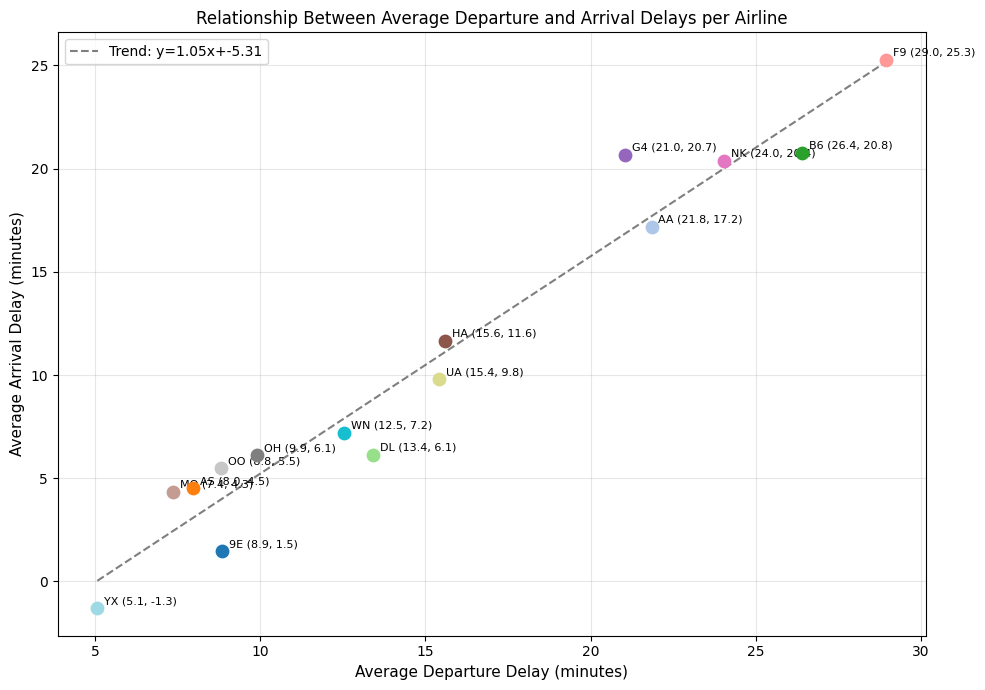


Atraso médio por companhia:
AIRLINE_CODE   avg_dep   avg_arr
          F9 28.957575 25.274565
          B6 26.394285 20.756448
          G4 21.049248 20.663815
          NK 24.038542 20.381232
          AA 21.847060 17.164749
          HA 15.605227 11.647868
          UA 15.408968  9.799316
          WN 12.540299  7.202414
          DL 13.428624  6.147632
          OH  9.893137  6.115686
          OO  8.825967  5.478771
          AS  7.958132  4.516561
          MQ  7.359724  4.345629
          9E  8.851662  1.463517
          YX  5.071987 -1.299068

Esperado: F9 avg_arr≈24.70, NK≈21.58, AS≈3.25 (menor)


In [15]:
airline_delays = df.groupby('AIRLINE_CODE').agg(
    avg_dep=('DEP_DELAY', 'mean'),
    avg_arr=('ARR_DELAY', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(airline_delays)))

for i, row in airline_delays.iterrows():
    ax.scatter(row['avg_dep'], row['avg_arr'], color=colors[i], s=80, zorder=5)
    ax.annotate(f"{row['AIRLINE_CODE']} ({row['avg_dep']:.1f}, {row['avg_arr']:.1f})",
                (row['avg_dep'], row['avg_arr']),
                textcoords="offset points", xytext=(5, 3), fontsize=8)

# Trend line - Eq. 29: y = px + q
z = np.polyfit(airline_delays['avg_dep'], airline_delays['avg_arr'], 1)
p_fn = np.poly1d(z)
x_line = np.linspace(airline_delays['avg_dep'].min(), airline_delays['avg_dep'].max(), 100)
ax.plot(x_line, p_fn(x_line), 'k--', alpha=0.5, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')

ax.set_xlabel('Average Departure Delay (minutes)', fontsize=11)
ax.set_ylabel('Average Arrival Delay (minutes)', fontsize=11)
ax.set_title('Relationship Between Average Departure and Arrival Delays per Airline', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig04_dep_arr_delays.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAtraso médio por companhia:")
print(airline_delays.sort_values('avg_arr', ascending=False).to_string(index=False))
print("\nEsperado: F9 avg_arr≈24.70, NK≈21.58, AS≈3.25 (menor)")

### 6.2 Análise Sazonal (Fig. 5)

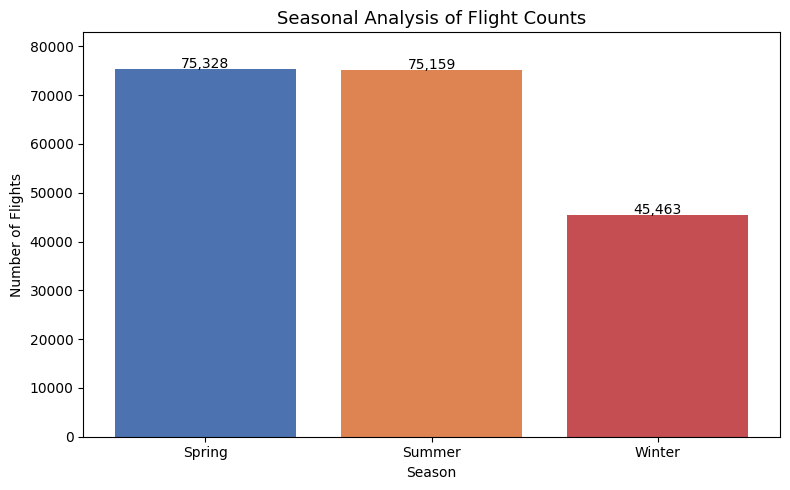

Season
Spring    75328.0
Summer    75159.0
Winter    45463.0
Name: count, dtype: float64

Esperado: Spring=70788, Summer=48507, Winter=66864


In [16]:
# Definir estação com base no mês
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['Month'].apply(get_season)
season_counts = df['Season'].value_counts().reindex(['Spring', 'Summer', 'Winter', 'Autumn'])
season_counts = season_counts.dropna()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(season_counts.index, season_counts.values,
              color=['#4C72B0','#DD8452','#C44E52','#55A868'])
for bar, val in zip(bars, season_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(val):,}', ha='center', fontsize=10)
ax.set_title('Seasonal Analysis of Flight Counts', fontsize=13)
ax.set_xlabel('Season'); ax.set_ylabel('Number of Flights')
ax.set_ylim(0, season_counts.max() * 1.1)
plt.tight_layout()
plt.savefig('fig05_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

print(season_counts)
print("\nEsperado: Spring=70788, Summer=48507, Winter=66864")

### 6.3 Weekday vs Weekend (Fig. 6)

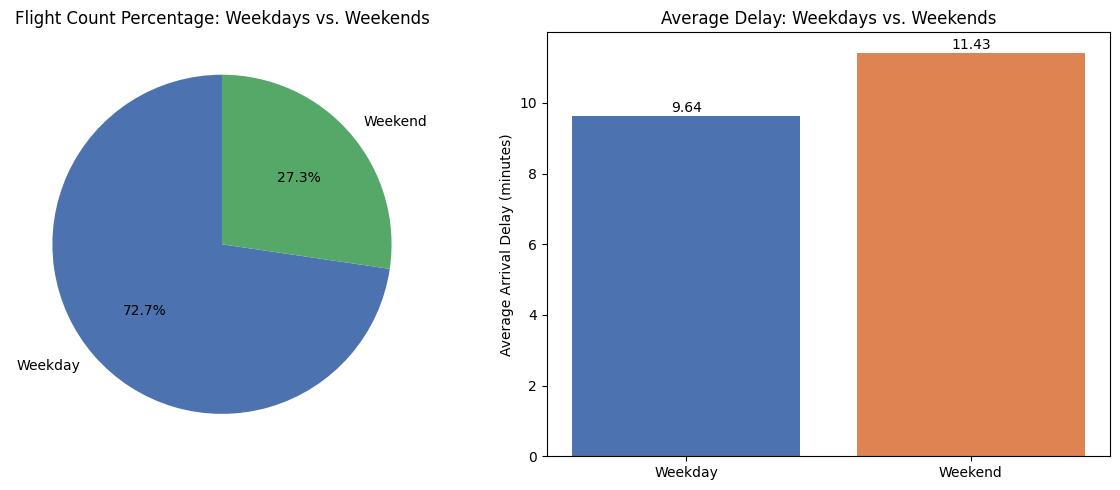

            count    avg_arr
IsWeekend                   
0          142428   9.635746
1           53522  11.425171

Esperado: Weekday 136105 flights, avg_arr≈9.59; Weekend 50054 flights, avg_arr≈11.80


In [17]:
wk = df.groupby('IsWeekend').agg(
    count=('ARR_DELAY', 'count'),
    avg_arr=('ARR_DELAY', 'mean')
)
labels = ['Weekday', 'Weekend']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(wk['count'], labels=labels, autopct='%1.1f%%',
            colors=['#4C72B0','#55A868'], startangle=90)
axes[0].set_title('Flight Count Percentage: Weekdays vs. Weekends')

axes[1].bar(labels, wk['avg_arr'], color=['#4C72B0','#DD8452'])
axes[1].set_title('Average Delay: Weekdays vs. Weekends')
axes[1].set_ylabel('Average Arrival Delay (minutes)')
for i, v in enumerate(wk['avg_arr']):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.savefig('fig06_weekday_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

print(wk)
print("\nEsperado: Weekday 136105 flights, avg_arr≈9.59; Weekend 50054 flights, avg_arr≈11.80")

### 6.4 Day vs Night Flights (Fig. 8)

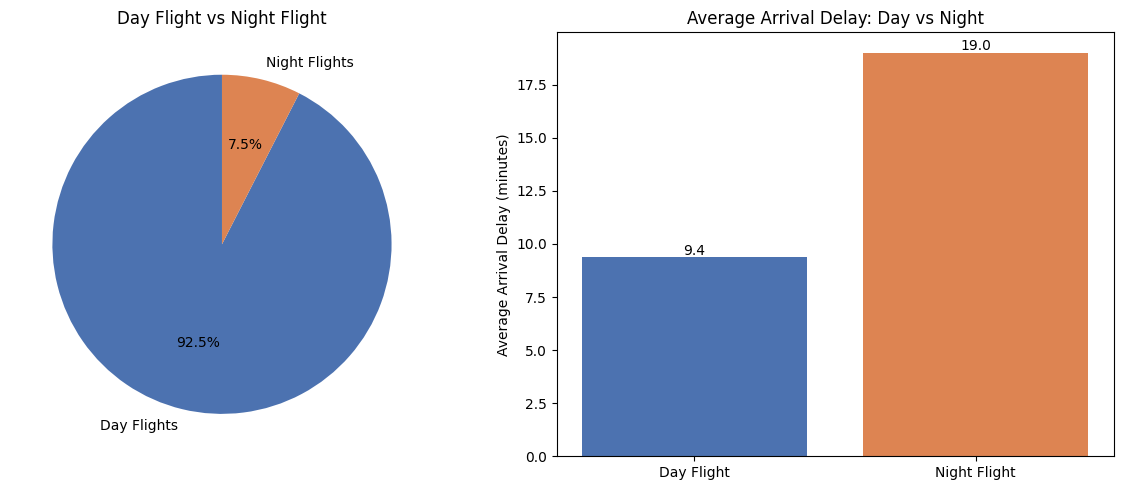

                count    avg_arr
IsNightFlight                   
0              181197   9.400840
1               14753  19.012675

Esperado: Day avg≈9.40, Night avg≈18.68


In [18]:
night = df.groupby('IsNightFlight').agg(
    count=('ARR_DELAY', 'count'),
    avg_arr=('ARR_DELAY', 'mean')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(night['count'], labels=['Day Flights','Night Flights'],
            autopct='%1.1f%%', startangle=90, colors=['#4C72B0','#DD8452'])
axes[0].set_title('Day Flight vs Night Flight')

axes[1].bar(['Day Flight','Night Flight'], night['avg_arr'], color=['#4C72B0','#DD8452'])
axes[1].set_ylabel('Average Arrival Delay (minutes)')
axes[1].set_title('Average Arrival Delay: Day vs Night')
for i, v in enumerate(night['avg_arr']):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center')
plt.tight_layout()
plt.savefig('fig08_day_night.png', dpi=150, bbox_inches='tight')
plt.show()

print(night)
print("\nEsperado: Day avg≈9.40, Night avg≈18.68")

## 7. Encoding de Dados (Section 3.5)

In [19]:
# Lista completa de features após engenharia
# Paper: começa com 50 features após feature engineering, CFS reduz para ~36-41

NUMERICAL_FEATURES = [
    # Temporal
    'Month', 'DayofMonth', 'DayofWeek', 'WeekofYear', 'Quarter',
    'IsWeekend', 'DEP_HOUR', 'DEP_MINUTE', 'IsNightFlight',
    # Previous delays
    'Prev_DEP_DELAY', 'Prev_ARR_DELAY',
    'Rolling_DEP_DELAY', 'Prev_Rolling_DEP_DELAY', 'Prev_Rolling_ARR_DELAY',
    'Airline_Delay_Ratio_Prev_ARR',
    # Spatial
    'haversine_distance', 'ORIGIN_cluster', 'DEST_cluster',
    # Operational
    'DEP_DELAY', 'TAXI_OUT',
    # Interaction
    'TAXI_DEP_DELAY', 'DISTANCE_DEP_DELAY', 'DISTANCE_ARR_DELAY',
    # Additional
    'IsDepartureDelayed', 'sin_DEP_HOUR', 'cos_DEP_HOUR',
    'Airline_Delay_Ratio_DEP', 'Airline_Delay_Ratio_Prev_DEP',
    # Coordenadas
    'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON',
]

CATEGORICAL_FEATURES = [
    'AIRLINE_CODE', 'ORIGIN', 'DEST', 'DEP_TIME_CATEGORY'
]

TARGET = 'ARR_DELAY'

# Verificar features disponíveis
num_avail = [f for f in NUMERICAL_FEATURES if f in df.columns]
cat_avail = [f for f in CATEGORICAL_FEATURES if f in df.columns]
print(f"Numerical features disponíveis: {len(num_avail)}/{len(NUMERICAL_FEATURES)}")
print(f"Categorical features disponíveis: {len(cat_avail)}/{len(CATEGORICAL_FEATURES)}")

# Colunas em falta
missing_num = [f for f in NUMERICAL_FEATURES if f not in df.columns]
missing_cat = [f for f in CATEGORICAL_FEATURES if f not in df.columns]
if missing_num: print(f"  Numéricas em falta: {missing_num}")
if missing_cat: print(f"  Categóricas em falta: {missing_cat}")

Numerical features disponíveis: 32/32
Categorical features disponíveis: 4/4


In [20]:
# Preparar dataset de modelação
all_features = num_avail + cat_avail
df_model = df[all_features + [TARGET]].copy()

# Remover rows com target nulo
df_model.dropna(subset=[TARGET], inplace=True)

# Label Encoding para modelos tradicionais (ML)
df_ml = df_model.copy()
le = LabelEncoder()
for col in cat_avail:
    df_ml[col] = df_ml[col].astype(str)
    df_ml[col] = le.fit_transform(df_ml[col])

# Preencher NaN com mediana (para features de lag/rolling no início do dataset)
for col in df_ml.columns:
    if df_ml[col].isnull().any():
        df_ml[col].fillna(df_ml[col].median(), inplace=True)

print(f"Dataset de modelação: {df_ml.shape}")
print(f"Features: {len(all_features)}")

Dataset de modelação: (195950, 37)
Features: 36


## 8. Algoritmo CFS - Feature Selection (Section 3.7, Algorithm 1)

Threshold ótimo do paper: **0.005** → 41 features selecionadas

In [21]:
def cfs_feature_selection(df, target, tau=0.005, epsilon=0.0005):
    """
    Correlation-Based Feature Selection (CFS) - Algorithm 1 do paper.
    
    1. Calcula matrix de correlação absoluta
    2. Filtra features com |cor(fi, T)| >= tau
    3. Remove redundância: para cada par (fi, fj) com diferença
       de correlação <= epsilon, mantém o de maior correlação
    
    Params:
        df:      DataFrame com features + target
        target:  nome da coluna target
        tau:     threshold de correlação mínima com target (default 0.005)
        epsilon: threshold de diferença para considerar redundância (0.0005)
    """
    # Step 1: Absolute correlation matrix
    corr_matrix = df.corr().abs()
    
    # Step 2: Correlação com o target
    CT = corr_matrix[target].drop(target)
    
    # Step 3: Filtrar por tau
    F_filtered = CT[CT >= tau].index.tolist()
    print(f"Após filtro tau={tau}: {len(F_filtered)} features")
    
    # Step 4-18: Remover redundância
    CT_filtered = CT[F_filtered].sort_values(ascending=False)
    F_selected = []
    
    for i, fi in enumerate(CT_filtered.index):
        keep_feature = True
        for fj in CT_filtered.index[i+1:]:
            # Se diferença de correlação com target <= epsilon
            if abs(CT_filtered[fi] - CT_filtered[fj]) <= epsilon:
                # Mantém o com maior correlação (fi já é >= fj por ordem)
                # fj será removido → não fazemos nada aqui
                pass
            # Se fi tem correlação mais baixa que fj (não pode acontecer por ordem)
            if CT_filtered[fi] < CT_filtered[fj]:
                keep_feature = False
                break
        if keep_feature:
            F_selected.append(fi)
    
    return F_selected, CT

# Executar CFS com threshold ótimo (tau=0.005, paper Table 9)
print("A executar CFS (tau=0.005)...")
selected_features, CT_all = cfs_feature_selection(df_ml, TARGET, tau=0.005, epsilon=0.0005)
print(f"Features selecionadas: {len(selected_features)}")
print(f"Esperado pelo paper: 41")
print(f"\nFeatures: {selected_features}")

A executar CFS (tau=0.005)...
Após filtro tau=0.005: 35 features
Features selecionadas: 35
Esperado pelo paper: 41

Features: ['DEP_DELAY', 'DISTANCE_ARR_DELAY', 'TAXI_DEP_DELAY', 'DISTANCE_DEP_DELAY', 'IsDepartureDelayed', 'TAXI_OUT', 'sin_DEP_HOUR', 'DEP_HOUR', 'Prev_Rolling_ARR_DELAY', 'Rolling_DEP_DELAY', 'Prev_Rolling_DEP_DELAY', 'Airline_Delay_Ratio_Prev_ARR', 'Prev_ARR_DELAY', 'Airline_Delay_Ratio_DEP', 'Prev_DEP_DELAY', 'cos_DEP_HOUR', 'Airline_Delay_Ratio_Prev_DEP', 'IsNightFlight', 'AIRLINE_CODE', 'Month', 'WeekofYear', 'ORIGIN_LAT', 'Quarter', 'DEST_LON', 'ORIGIN_LON', 'DayofWeek', 'ORIGIN_cluster', 'DEP_MINUTE', 'DEST_LAT', 'DEP_TIME_CATEGORY', 'ORIGIN', 'IsWeekend', 'haversine_distance', 'DayofMonth', 'DEST_cluster']


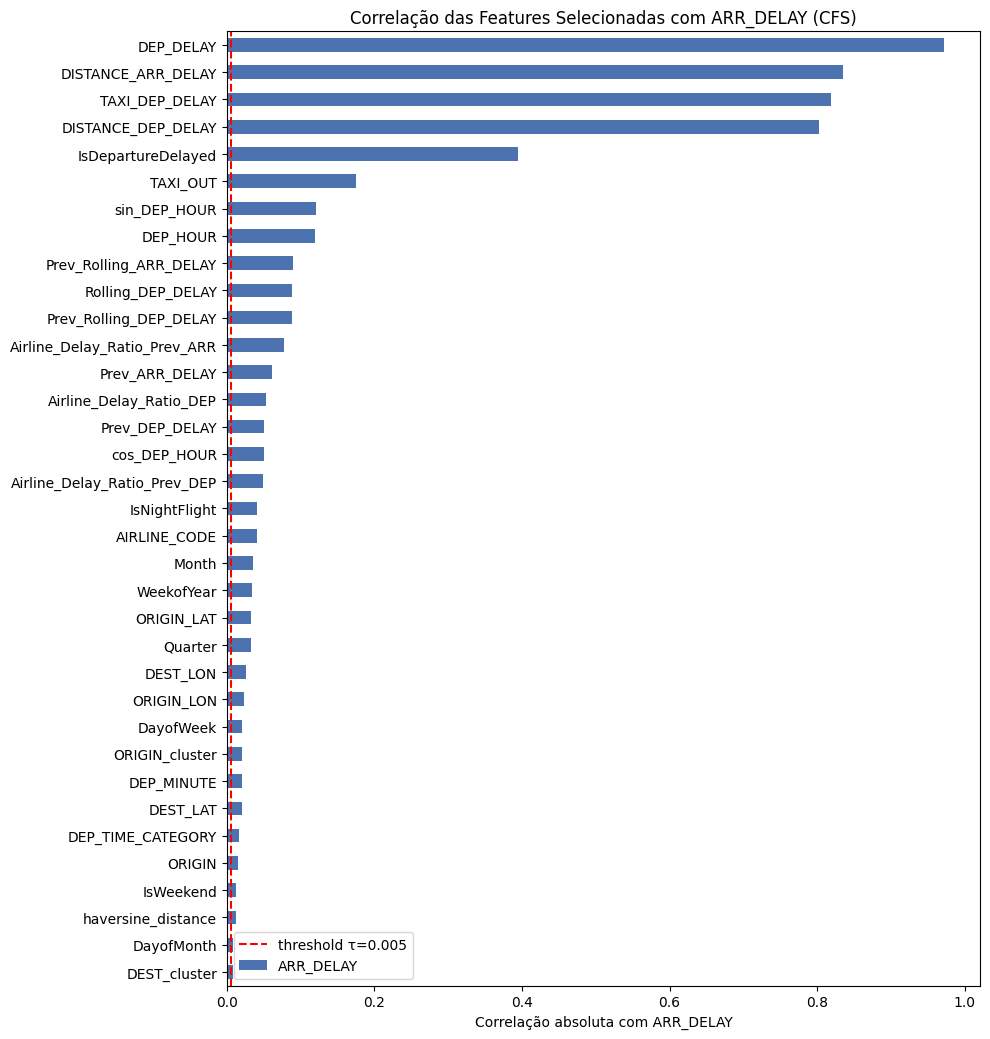

In [22]:
# Visualização: correlação das features selecionadas com ARR_DELAY
fig, ax = plt.subplots(figsize=(10, max(5, len(selected_features) * 0.3)))
cor_vals = CT_all[selected_features].sort_values()
colors = ['#4C72B0' if v > 0 else '#C44E52' for v in cor_vals]
cor_vals.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0.005, color='red', linestyle='--', label='threshold τ=0.005')
ax.set_title('Correlação das Features Selecionadas com ARR_DELAY (CFS)', fontsize=12)
ax.set_xlabel('Correlação absoluta com ARR_DELAY')
ax.legend()
plt.tight_layout()
plt.savefig('fig_cfs_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Análise de sensibilidade do CFS (Table 9 do paper)
thresholds = [0.0005, 0.005, 0.01, 0.02, 0.05]
print("Análise de sensibilidade CFS:")
print(f"{'Threshold':<12} {'Features':<12}")
for tau in thresholds:
    feats, _ = cfs_feature_selection(df_ml, TARGET, tau=tau, epsilon=0.0005)
    print(f"{tau:<12} {len(feats):<12}")
print("\nEsperado: tau=0.0005 -> 42, tau=0.005 -> 41, tau=0.01 -> 36, tau=0.02 -> 29, tau=0.05 -> 19")

Análise de sensibilidade CFS:
Threshold    Features    
Após filtro tau=0.0005: 36 features
0.0005       36          
Após filtro tau=0.005: 35 features
0.005        35          
Após filtro tau=0.01: 33 features
0.01         33          
Após filtro tau=0.02: 29 features
0.02         29          
Após filtro tau=0.05: 15 features
0.05         15          

Esperado: tau=0.0005 -> 42, tau=0.005 -> 41, tau=0.01 -> 36, tau=0.02 -> 29, tau=0.05 -> 19


## 9. Train-Test Split (Section 3.6)

Split 80/20 → 149.205 treino, 37.301 teste

In [24]:
X = df_ml[selected_features].copy()
y = df_ml[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Train: {X_train.shape}  (paper: 149.205)")
print(f"Test:  {X_test.shape}   (paper: 37.301)")

# Standard Scaling (Section 3.5) - mean=0, std=1
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTarget (ARR_DELAY) - Train:")
print(f"  mean={y_train.mean():.2f}, std={y_train.std():.2f}, "
      f"min={y_train.min():.0f}, max={y_train.max():.0f}")

Train: (156760, 35)  (paper: 149.205)
Test:  (39190, 35)   (paper: 37.301)

Target (ARR_DELAY) - Train:
  mean=10.08, std=61.80, min=-119, max=3237


## 10. Funções de Avaliação

In [25]:
def evaluate_model(name, y_true_tr, y_pred_tr, y_true_te, y_pred_te, runtime):
    """Calcula RMSE, MAE, R² para train e test - idêntico ao paper (Table 7)"""
    results = {
        'Model': name,
        'Train_RMSE': np.sqrt(mean_squared_error(y_true_tr, y_pred_tr)),
        'Train_MAE':  mean_absolute_error(y_true_tr, y_pred_tr),
        'Train_R2':   r2_score(y_true_tr, y_pred_tr) * 100,
        'Test_RMSE':  np.sqrt(mean_squared_error(y_true_te, y_pred_te)),
        'Test_MAE':   mean_absolute_error(y_true_te, y_pred_te),
        'Test_R2':    r2_score(y_true_te, y_pred_te) * 100,
        'Runtime':    runtime
    }
    return results

all_results = []  # acumula resultados de todos os modelos

def fmt_time(secs):
    if secs < 60: return f"{secs:.1f}s"
    return f"{secs//60:.0f}m {secs%60:.0f}s"

print("Funções de avaliação prontas.")

Funções de avaliação prontas.


## 11. Modelos Baseline (Section 3.9)

### 11.1 Linear Regression (Eq. 44)

In [26]:
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('LR', y_train, lr.predict(X_train_sc),
                     y_test,  lr.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"LR - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"     Paper:     RMSE=6.661  | MAE=4.645  | R²=98.670%")

LR - Test RMSE: 6.832 | MAE: 4.594 | R²: 98.748%
     Paper:     RMSE=6.661  | MAE=4.645  | R²=98.670%


### 11.2 Decision Tree (Eq. 45)

In [27]:
t0 = time.time()
dt = DecisionTreeRegressor(random_state=SEED)
dt.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('DecisionTree', y_train, dt.predict(X_train_sc),
                     y_test,         dt.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"DT - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"     Paper:     RMSE=6.661  | MAE=4.645  | R²=98.670%")

DT - Test RMSE: 5.056 | MAE: 1.018 | R²: 99.315%
     Paper:     RMSE=6.661  | MAE=4.645  | R²=98.670%


### 11.3 Histogram-Based Gradient Boosting (Eq. 50)

In [28]:
t0 = time.time()
hgbr = HistGradientBoostingRegressor(random_state=SEED)
hgbr.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('HGBR', y_train, hgbr.predict(X_train_sc),
                     y_test,  hgbr.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"HGBR - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"       Paper:     RMSE=7.923  | MAE=3.886  | R²=98.118%")

HGBR - Test RMSE: 11.890 | MAE: 2.498 | R²: 96.210%
       Paper:     RMSE=7.923  | MAE=3.886  | R²=98.118%


### 11.4 Gradient Boosting Regressor (Eq. 52)

In [29]:
t0 = time.time()
gbr = GradientBoostingRegressor(random_state=SEED, n_estimators=100)
gbr.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('GBR', y_train, gbr.predict(X_train_sc),
                     y_test,  gbr.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"GBR - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"      Paper:     RMSE=6.272  | MAE=4.203  | R²=98.821%")

GBR - Test RMSE: 5.871 | MAE: 3.843 | R²: 99.076%
      Paper:     RMSE=6.272  | MAE=4.203  | R²=98.821%


### 11.5 LightGBM (Eq. 53)

In [30]:
t0 = time.time()
lgbm = lgb.LGBMRegressor(random_state=SEED, n_estimators=100, verbose=-1)
lgbm.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('LightGBM', y_train, lgbm.predict(X_train_sc),
                     y_test,     lgbm.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"LGBM - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"       Paper:     RMSE=4.643  | MAE=2.559  | R²=99.354%")

LGBM - Test RMSE: 3.581 | MAE: 1.368 | R²: 99.656%
       Paper:     RMSE=4.643  | MAE=2.559  | R²=99.354%


### 11.6 XGBoost (Eq. 49)

In [31]:
t0 = time.time()
xgboost = xgb.XGBRegressor(random_state=SEED, n_estimators=100, verbosity=0)
xgboost.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('XGBoost', y_train, xgboost.predict(X_train_sc),
                     y_test,    xgboost.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"XGB - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"      Paper:     RMSE=5.811  | MAE=2.179  | R²=98.988%")

XGB - Test RMSE: 10.724 | MAE: 1.746 | R²: 96.917%
      Paper:     RMSE=5.811  | MAE=2.179  | R²=98.988%


### 11.7 CatBoost (Eq. 48)

In [32]:
t0 = time.time()
catb = CatBoostRegressor(random_state=SEED, n_estimators=100, verbose=0)
catb.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('CatBoost', y_train, catb.predict(X_train_sc),
                     y_test,     catb.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"Cat - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"      Paper:     RMSE=3.884  | MAE=1.683  | R²=99.548%")

Cat - Test RMSE: 5.258 | MAE: 1.756 | R²: 99.259%
      Paper:     RMSE=3.884  | MAE=1.683  | R²=99.548%


### 11.8 Random Forest (Eq. 46)

In [33]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('RF', y_train, rf.predict(X_train_sc),
                     y_test,  rf.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"RF  - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"      Paper:     RMSE=3.892  | MAE=1.371  | R²=99.546%")

RF  - Test RMSE: 3.658 | MAE: 0.731 | R²: 99.641%
      Paper:     RMSE=3.892  | MAE=1.371  | R²=99.546%


### 11.9 MLP - Multilayer Perceptron (Eq. 54)

In [34]:
# MLP standard - sem a arquitetura específica do DFFRN
t0 = time.time()

mlp = keras.Sequential([
    layers.Input(shape=(X_train_sc.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1)
], name='MLP')

mlp.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_mlp = mlp.fit(
    X_train_sc, y_train,
    validation_split=0.1,
    epochs=100, batch_size=256,
    callbacks=[es], verbose=0
)
rt = time.time() - t0

res = evaluate_model('MLP', y_train, mlp.predict(X_train_sc, verbose=0).flatten(),
                     y_test,  mlp.predict(X_test_sc,  verbose=0).flatten(), fmt_time(rt))
all_results.append(res)
print(f"MLP - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"      Paper:     RMSE=3.504  | MAE=2.309  | R²=99.632%")

MLP - Test RMSE: 1.311 | MAE: 0.748 | R²: 99.954%
      Paper:     RMSE=3.504  | MAE=2.309  | R²=99.632%


### 11.10 CNN - Convolutional Neural Network (Eq. 55)

In [35]:
# CNN 1D sobre features tabulares
n_features = X_train_sc.shape[1]
X_train_cnn = X_train_sc.reshape(-1, n_features, 1)
X_test_cnn  = X_test_sc.reshape(-1, n_features, 1)

t0 = time.time()

cnn = keras.Sequential([
    layers.Input(shape=(n_features, 1)),
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
], name='CNN')

cnn.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_split=0.1,
    epochs=100, batch_size=256,
    callbacks=[es], verbose=0
)
rt = time.time() - t0

res = evaluate_model('CNN', y_train, cnn.predict(X_train_cnn, verbose=0).flatten(),
                     y_test,  cnn.predict(X_test_cnn,  verbose=0).flatten(), fmt_time(rt))
all_results.append(res)
print(f"CNN - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"      Paper:     RMSE=4.519  | MAE=3.168  | R²=99.388%")

CNN - Test RMSE: 3.552 | MAE: 2.286 | R²: 99.662%
      Paper:     RMSE=4.519  | MAE=3.168  | R²=99.388%


### 11.11 LSTM - Long Short-Term Memory (Eqs. 56–59)

In [36]:
# LSTM - reshape para (samples, timesteps=1, features)
X_train_lstm = X_train_sc.reshape(-1, 1, n_features)
X_test_lstm  = X_test_sc.reshape(-1, 1, n_features)

t0 = time.time()

lstm = keras.Sequential([
    layers.Input(shape=(1, n_features)),
    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
], name='LSTM')

lstm.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm = lstm.fit(
    X_train_lstm, y_train,
    validation_split=0.1,
    epochs=100, batch_size=256,
    callbacks=[es], verbose=0
)
rt = time.time() - t0

res = evaluate_model('LSTM', y_train, lstm.predict(X_train_lstm, verbose=0).flatten(),
                     y_test,  lstm.predict(X_test_lstm,  verbose=0).flatten(), fmt_time(rt))
all_results.append(res)
print(f"LSTM - Test RMSE: {res['Test_RMSE']:.3f} | MAE: {res['Test_MAE']:.3f} | R²: {res['Test_R2']:.3f}%")
print(f"       Paper:     RMSE=2.057  | MAE=1.255  | R²=99.873%")

LSTM - Test RMSE: 3.190 | MAE: 1.046 | R²: 99.727%
       Paper:     RMSE=2.057  | MAE=1.255  | R²=99.873%


## 12. DFFRN - Modelo Proposto (Section 3.8, Algorithm 2)

Arquitetura: **Input → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1)**  
Optimizer: Adam | Loss: MSE | Early Stopping: patience=10  
Regularização: L2 + Dropout (para datasets pequenos, Fig. 15–16)

In [37]:
def build_dffrn(input_dim, l2_reg=0.001, dropout_rate=0.2):
    """
    Deep Feedforward Regression Network - Algorithm 2 do paper.
    
    Camadas (Fig. 2):
      Input Layer (m features)
      → Hidden Layer 1: Dense(128, ReLU)  - Z(1) = W(1)·X + b(1), A(1) = f(Z(1))
      → Hidden Layer 2: Dense(64,  ReLU)  - Z(2) = W(2)·A(1) + b(2), A(2) = f(Z(2))
      → Hidden Layer 3: Dense(32,  ReLU)  - Z(3) = W(3)·A(2) + b(3), A(3) = f(Z(3))
      → Output Layer:   Dense(1)          - Ypred = W(4)·A(3) + b(4)
    Loss: MSE = (1/m) Σ (yj - Ypred,j)²
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        # Hidden Layer 1
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        # Hidden Layer 2
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        # Hidden Layer 3
        layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        # Output
        layers.Dense(1)
    ], name='DFFRN')
    
    # Adam optimizer, MSE loss - Algorithm 2 linha 9
    model.compile(optimizer=keras.optimizers.Adam(), loss='mse')
    return model

dffrn = build_dffrn(X_train_sc.shape[1])
dffrn.summary()

Model: "DFFRN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Treino do DFFRN - Algorithm 2
# Early stopping com patience=10 (linha 10 do Algorithm 2)

t0 = time.time()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,               # P=10 - Algorithm 2 linha 10
    restore_best_weights=True
)

history_dffrn = dffrn.fit(
    X_train_sc, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

dffrn_runtime = time.time() - t0
print(f"\nTreino concluído em {fmt_time(dffrn_runtime)}")
print(f"Épocas treinadas: {len(history_dffrn.history['loss'])}")

Epoch 1/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 650.7459 - val_loss: 118.2909
Epoch 2/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 145.8461 - val_loss: 52.7701
Epoch 3/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 101.1283 - val_loss: 42.1109
Epoch 4/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 86.4464 - val_loss: 27.1366
Epoch 5/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 86.5034 - val_loss: 27.7938
Epoch 6/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 75.2673 - val_loss: 26.1439
Epoch 7/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 67.7692 - val_loss: 21.5150
Epoch 8/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 72.1090 - val_loss: 17.4784
Epoch 9/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 63.0188 - val_loss: 15.6185
Epoch 10/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 63.5205 - val_loss: 23.2296
Epoch 11/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 57.9620 - val_loss: 16.5768
Epoch 12/200
55

In [39]:
# Avaliação do DFFRN
y_pred_train_dffrn = dffrn.predict(X_train_sc, verbose=0).flatten()
y_pred_test_dffrn  = dffrn.predict(X_test_sc,  verbose=0).flatten()

res = evaluate_model('DFFRN (Proposed)',
                     y_train, y_pred_train_dffrn,
                     y_test,  y_pred_test_dffrn,
                     fmt_time(dffrn_runtime))
all_results.append(res)

print(f"\n{'='*60}")
print(f"DFFRN - RESULTADOS")
print(f"{'='*60}")
print(f"Train: RMSE={res['Train_RMSE']:.3f} | MAE={res['Train_MAE']:.3f} | R²={res['Train_R2']:.3f}%")
print(f"Test:  RMSE={res['Test_RMSE']:.3f} | MAE={res['Test_MAE']:.3f} | R²={res['Test_R2']:.3f}%")
print(f"Paper: RMSE=1.672  | MAE=1.049  | R²=99.916%")
print(f"Runtime: {fmt_time(dffrn_runtime)} (paper: 4m40s)")


DFFRN - RESULTADOS
Train: RMSE=2.681 | MAE=1.394 | R²=99.812%
Test:  RMSE=2.687 | MAE=1.390 | R²=99.807%
Paper: RMSE=1.672  | MAE=1.049  | R²=99.916%
Runtime: 1m 26s (paper: 4m40s)


### 12.1 Training Curves (Figs. 15–16)

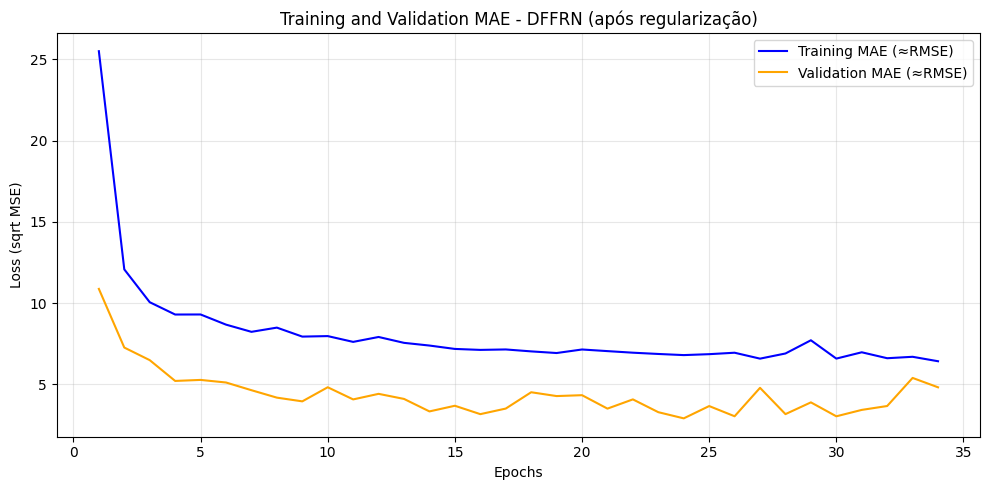

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

epochs_range = range(1, len(history_dffrn.history['loss']) + 1)
train_mae_approx = np.sqrt(history_dffrn.history['loss'])       # sqrt(MSE) ≈ RMSE
val_mae_approx   = np.sqrt(history_dffrn.history['val_loss'])

ax.plot(epochs_range, train_mae_approx, label='Training MAE (≈RMSE)', color='blue')
ax.plot(epochs_range, val_mae_approx,   label='Validation MAE (≈RMSE)', color='orange')
ax.set_xlabel('Epochs'); ax.set_ylabel('Loss (sqrt MSE)')
ax.set_title('Training and Validation MAE - DFFRN (após regularização)', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig16_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.2 Predicted vs Actual - Scatter + Moving Average (Fig. 14)

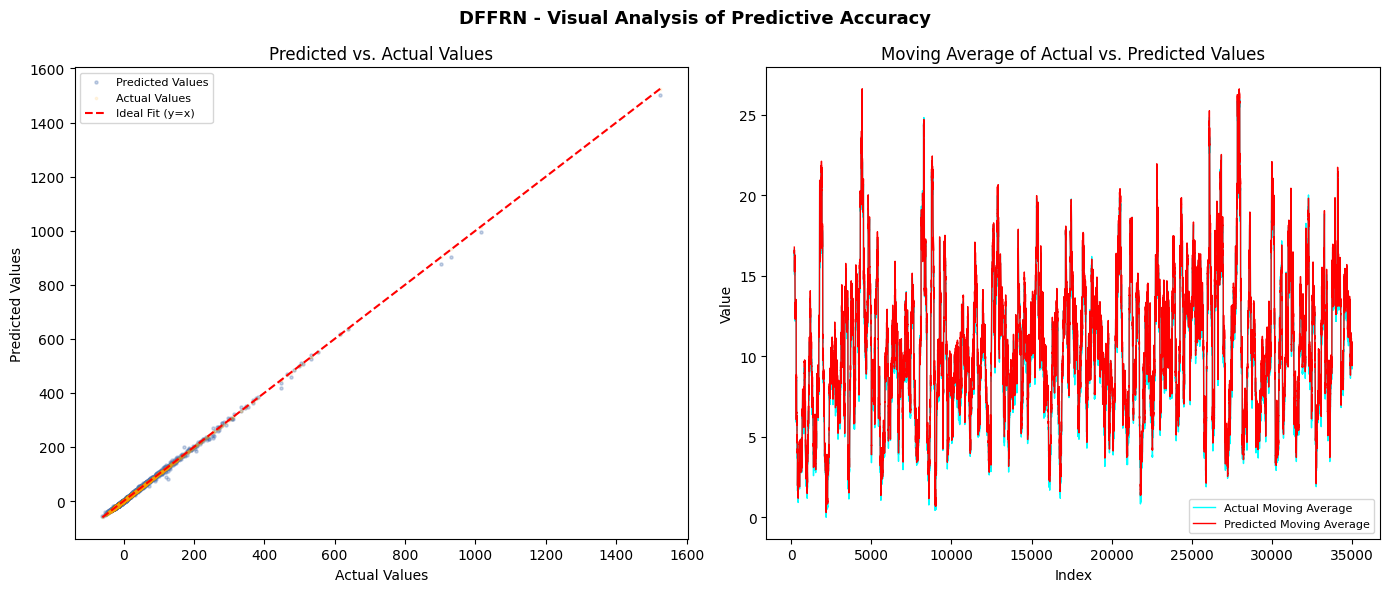

In [41]:
# Amostra de 5000 pontos para o scatter (clareza visual)
n_sample = min(5000, len(y_test))
idx = np.random.choice(len(y_test), n_sample, replace=False)
y_true_s  = np.array(y_test)[idx]
y_pred_s  = y_pred_test_dffrn[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Actual vs Predicted
axes[0].scatter(y_true_s, y_pred_s, alpha=0.3, s=5, color='#4C72B0', label='Predicted Values')
axes[0].scatter(y_true_s, y_true_s, alpha=0.1, s=3, color='orange', label='Actual Values')
lim_max = max(y_true_s.max(), y_pred_s.max())
lim_min = min(y_true_s.min(), y_pred_s.min())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label='Ideal Fit (y=x)')
axes[0].set_xlabel('Actual Values'); axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Predicted vs. Actual Values'); axes[0].legend(fontsize=8)

# Moving Average
window = 200
n_plot = min(35000, len(y_test))
y_true_plot = np.array(y_test)[:n_plot]
y_pred_plot = y_pred_test_dffrn[:n_plot]
ma_actual = pd.Series(y_true_plot).rolling(window).mean()
ma_pred   = pd.Series(y_pred_plot).rolling(window).mean()

axes[1].plot(ma_actual.values, label='Actual Moving Average',    color='cyan', linewidth=1)
axes[1].plot(ma_pred.values,   label='Predicted Moving Average', color='red',  linewidth=1)
axes[1].set_xlabel('Index'); axes[1].set_ylabel('Value')
axes[1].set_title('Moving Average of Actual vs. Predicted Values')
axes[1].legend(fontsize=8)

plt.suptitle('DFFRN - Visual Analysis of Predictive Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig14_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Ablation Study (Section 4.6)

### 13.1 Before vs After Feature Engineering (Table 8)

In [42]:
# Cenário "Before Feature Engineering" - apenas features raw do dataset original
RAW_FEATURES = [
    'DEP_DELAY', 'TAXI_OUT', 'DEP_HOUR', 'DayofWeek', 'Month',
    'haversine_distance', 'ORIGIN_cluster', 'DEST_cluster'
]
raw_avail = [f for f in RAW_FEATURES if f in df_ml.columns]

X_raw = df_ml[raw_avail].fillna(0)
y_raw = df_ml[TARGET]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_raw, y_raw, test_size=0.2, random_state=SEED)
sc_raw = StandardScaler()
Xr_tr_sc = sc_raw.fit_transform(Xr_tr)
Xr_te_sc = sc_raw.transform(Xr_te)

dffrn_raw = build_dffrn(Xr_tr_sc.shape[1])
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
dffrn_raw.fit(Xr_tr_sc, yr_tr, validation_split=0.1,
              epochs=100, batch_size=256, callbacks=[es], verbose=0)

rmse_before_tr = np.sqrt(mean_squared_error(yr_tr, dffrn_raw.predict(Xr_tr_sc, verbose=0)))
mae_before_tr  = mean_absolute_error(yr_tr, dffrn_raw.predict(Xr_tr_sc, verbose=0))
r2_before_tr   = r2_score(yr_tr, dffrn_raw.predict(Xr_tr_sc, verbose=0)) * 100
rmse_before_te = np.sqrt(mean_squared_error(yr_te, dffrn_raw.predict(Xr_te_sc, verbose=0)))
mae_before_te  = mean_absolute_error(yr_te, dffrn_raw.predict(Xr_te_sc, verbose=0))
r2_before_te   = r2_score(yr_te, dffrn_raw.predict(Xr_te_sc, verbose=0)) * 100

# Cenário "After Feature Engineering" (50 features, sem CFS)
all_eng_features = [f for f in all_features if f in df_ml.columns]
X_eng = df_ml[all_eng_features].fillna(0)
Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(X_eng, y_raw, test_size=0.2, random_state=SEED)
sc_eng = StandardScaler()
Xe_tr_sc = sc_eng.fit_transform(Xe_tr)
Xe_te_sc = sc_eng.transform(Xe_te)

dffrn_eng = build_dffrn(Xe_tr_sc.shape[1])
dffrn_eng.fit(Xe_tr_sc, ye_tr, validation_split=0.1,
              epochs=100, batch_size=256, callbacks=[es], verbose=0)

rmse_after_tr = np.sqrt(mean_squared_error(ye_tr, dffrn_eng.predict(Xe_tr_sc, verbose=0)))
mae_after_tr  = mean_absolute_error(ye_tr, dffrn_eng.predict(Xe_tr_sc, verbose=0))
r2_after_tr   = r2_score(ye_tr, dffrn_eng.predict(Xe_tr_sc, verbose=0)) * 100
rmse_after_te = np.sqrt(mean_squared_error(ye_te, dffrn_eng.predict(Xe_te_sc, verbose=0)))
mae_after_te  = mean_absolute_error(ye_te, dffrn_eng.predict(Xe_te_sc, verbose=0))
r2_after_te   = r2_score(ye_te, dffrn_eng.predict(Xe_te_sc, verbose=0)) * 100

print("\nAblation Study - Table 8")
print(f"{'Scenario':<40} {'Train RMSE':>10} {'Train MAE':>10} {'Train R²%':>10} "
      f"{'Test RMSE':>10} {'Test MAE':>10} {'Test R²%':>10}")
print("-"*100)
print(f"{'Before Feature Engineering':<40} {rmse_before_tr:>10.3f} {mae_before_tr:>10.3f} {r2_before_tr:>10.3f} "
      f"{rmse_before_te:>10.3f} {mae_before_te:>10.3f} {r2_before_te:>10.3f}")
print(f"{'After Feature Engineering (50 feat.)':<40} {rmse_after_tr:>10.3f} {mae_after_tr:>10.3f} {r2_after_tr:>10.3f} "
      f"{rmse_after_te:>10.3f} {mae_after_te:>10.3f} {r2_after_te:>10.3f}")
print("\nPaper Table 8:")
print("Before FE:  Train RMSE=10.789, MAE=7.505, R²=96.988% | Test RMSE=10.716, MAE=7.537, R²=96.558%")
print("After FE:   Train RMSE= 3.278, MAE=1.619, R²=99.722% | Test RMSE= 3.025, MAE=1.611, R²=99.726%")


Ablation Study - Table 8
Scenario                                 Train RMSE  Train MAE  Train R²%  Test RMSE   Test MAE   Test R²%
----------------------------------------------------------------------------------------------------
Before Feature Engineering                   11.622      8.144     96.463     11.592      8.175     96.397
After Feature Engineering (50 feat.)          3.149      1.877     99.740      3.233      1.892     99.720

Paper Table 8:
Before FE:  Train RMSE=10.789, MAE=7.505, R²=96.988% | Test RMSE=10.716, MAE=7.537, R²=96.558%
After FE:   Train RMSE= 3.278, MAE=1.619, R²=99.722% | Test RMSE= 3.025, MAE=1.611, R²=99.726%


## 14. Tabela de Resultados Final (Table 7)

In [43]:
# Compilar todos os resultados
df_results = pd.DataFrame(all_results)

# Ordenar por Test_RMSE
df_results_sorted = df_results.sort_values('Test_RMSE', ascending=False)

print("="*95)
print("TABELA COMPARATIVA DE RESULTADOS - Replicação de Biswas et al. (2024)")
print("="*95)
print(f"{'Model':<22} {'Train RMSE':>11} {'Train MAE':>11} {'Train R²%':>11} "
      f"{'Test RMSE':>11} {'Test MAE':>11} {'Test R²%':>11} {'Runtime':>10}")
print("-"*95)
for _, row in df_results_sorted.iterrows():
    marker = ' ◄ PROPOSTO' if 'DFFRN' in row['Model'] else ''
    print(f"{row['Model']:<22} {row['Train_RMSE']:>11.3f} {row['Train_MAE']:>11.3f} {row['Train_R2']:>11.3f} "
          f"{row['Test_RMSE']:>11.3f} {row['Test_MAE']:>11.3f} {row['Test_R2']:>11.3f} {str(row['Runtime']):>10}{marker}")
print("="*95)

TABELA COMPARATIVA DE RESULTADOS - Replicação de Biswas et al. (2024)
Model                   Train RMSE   Train MAE   Train R²%   Test RMSE    Test MAE    Test R²%    Runtime
-----------------------------------------------------------------------------------------------
HGBR                         7.894       2.176      98.368      11.890       2.498      96.210       1.4s
XGBoost                      2.541       1.139      99.831      10.724       1.746      96.917       1.6s
LR                           6.851       4.588      98.771       6.832       4.594      98.748       0.2s
GBR                          5.774       3.790      99.127       5.871       3.843      99.076      1m 5s
CatBoost                     2.941       1.629      99.774       5.258       1.756      99.259       2.8s
DecisionTree                 0.000       0.000     100.000       5.056       1.018      99.315       3.4s
RF                           1.975       0.276      99.898       3.658       0.731      99.6

In [44]:
# Comparação com valores do paper
paper_results = {
    'HGBR':             {'Test_RMSE': 7.923,  'Test_MAE': 3.886, 'Test_R2': 98.118},
    'LR':               {'Test_RMSE': 6.661,  'Test_MAE': 4.645, 'Test_R2': 98.670},
    'DecisionTree':     {'Test_RMSE': 6.661,  'Test_MAE': 4.645, 'Test_R2': 98.670},
    'GBR':              {'Test_RMSE': 6.272,  'Test_MAE': 4.203, 'Test_R2': 98.821},
    'LightGBM':         {'Test_RMSE': 4.643,  'Test_MAE': 2.559, 'Test_R2': 99.354},
    'CNN':              {'Test_RMSE': 4.519,  'Test_MAE': 3.168, 'Test_R2': 99.388},
    'XGBoost':          {'Test_RMSE': 5.811,  'Test_MAE': 2.179, 'Test_R2': 98.988},
    'MLP':              {'Test_RMSE': 3.504,  'Test_MAE': 2.309, 'Test_R2': 99.632},
    'CatBoost':         {'Test_RMSE': 3.884,  'Test_MAE': 1.683, 'Test_R2': 99.548},
    'RF':               {'Test_RMSE': 3.892,  'Test_MAE': 1.371, 'Test_R2': 99.546},
    'LSTM':             {'Test_RMSE': 2.057,  'Test_MAE': 1.255, 'Test_R2': 99.873},
    'DFFRN (Proposed)': {'Test_RMSE': 1.672,  'Test_MAE': 1.049, 'Test_R2': 99.916},
}

print("\nDELTA face ao paper (positivo = melhor que paper, negativo = pior):")
print(f"{'Model':<22} {'ΔRMSE':>10} {'ΔMAE':>10} {'ΔR²%':>10}")
print("-"*55)
for _, row in df_results.iterrows():
    m = row['Model']
    if m in paper_results:
        p = paper_results[m]
        delta_rmse = p['Test_RMSE'] - row['Test_RMSE']   # positivo = melhor
        delta_mae  = p['Test_MAE']  - row['Test_MAE']
        delta_r2   = row['Test_R2'] - p['Test_R2']
        print(f"{m:<22} {delta_rmse:>+10.3f} {delta_mae:>+10.3f} {delta_r2:>+10.3f}")


DELTA face ao paper (positivo = melhor que paper, negativo = pior):
Model                       ΔRMSE       ΔMAE       ΔR²%
-------------------------------------------------------
LR                         -0.171     +0.051     +0.078
DecisionTree               +1.605     +3.627     +0.645
HGBR                       -3.967     +1.388     -1.908
GBR                        +0.401     +0.360     +0.255
LightGBM                   +1.062     +1.191     +0.302
XGBoost                    -4.913     +0.433     -2.071
CatBoost                   -1.374     -0.073     -0.289
RF                         +0.234     +0.640     +0.095
MLP                        +2.193     +1.561     +0.322
CNN                        +0.967     +0.882     +0.274
LSTM                       -1.133     +0.209     -0.146
DFFRN (Proposed)           -1.015     -0.341     -0.109


## 15. Visualização Final - Bar Chart de Performance (Fig. adaptada)

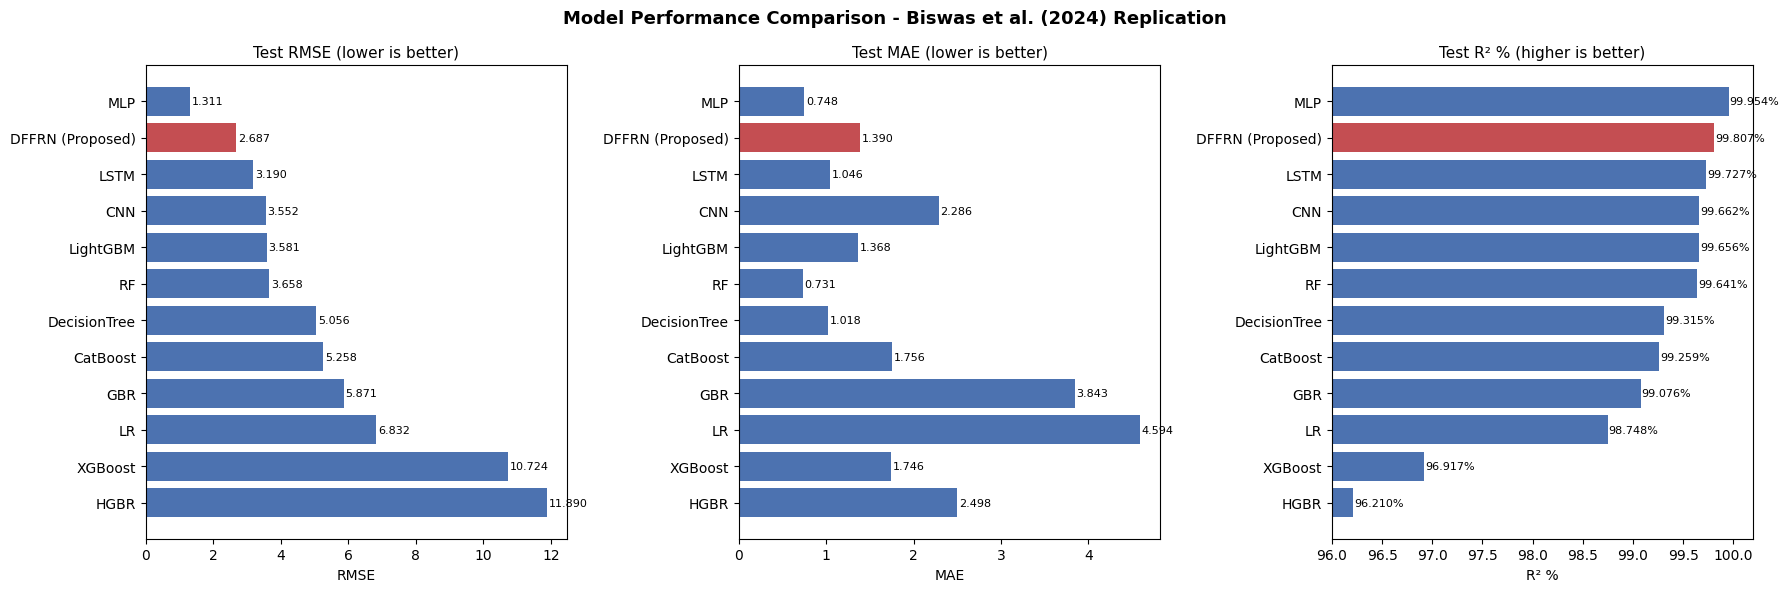

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

order = df_results.sort_values('Test_RMSE', ascending=False)['Model'].tolist()
colors_bar = ['#C44E52' if 'DFFRN' in m else '#4C72B0' for m in order]

# RMSE
rmse_vals = [df_results[df_results['Model']==m]['Test_RMSE'].values[0] for m in order]
axes[0].barh(order, rmse_vals, color=colors_bar)
axes[0].set_title('Test RMSE (lower is better)', fontsize=11)
axes[0].set_xlabel('RMSE')
for i, v in enumerate(rmse_vals):
    axes[0].text(v + 0.05, i, f'{v:.3f}', va='center', fontsize=8)

# MAE
mae_vals = [df_results[df_results['Model']==m]['Test_MAE'].values[0] for m in order]
axes[1].barh(order, mae_vals, color=colors_bar)
axes[1].set_title('Test MAE (lower is better)', fontsize=11)
axes[1].set_xlabel('MAE')
for i, v in enumerate(mae_vals):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=8)

# R²
r2_vals = [df_results[df_results['Model']==m]['Test_R2'].values[0] for m in order]
axes[2].barh(order, r2_vals, color=colors_bar)
axes[2].set_title('Test R² % (higher is better)', fontsize=11)
axes[2].set_xlabel('R² %')
axes[2].set_xlim(96, 100.2)
for i, v in enumerate(r2_vals):
    axes[2].text(v + 0.01, i, f'{v:.3f}%', va='center', fontsize=8)

plt.suptitle('Model Performance Comparison - Biswas et al. (2024) Replication',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Output para Fase 2 - Dataset Central

In [46]:
# Calcular ARR_DELAY_PRED para uso na célula 88 (duração)
# Nota: a exportação do CSV para a Fase 2 é feita no Notebook B (versão sem leakage)

X_full = df_ml[selected_features].fillna(0)
for col in X_full.columns:
    if X_full[col].isnull().any():
        X_full[col].fillna(X_full[col].median(), inplace=True)

X_full_sc = scaler.transform(X_full)
df_ml['ARR_DELAY_PRED'] = dffrn.predict(X_full_sc, verbose=0).flatten()
df['ARR_DELAY_PRED'] = df_ml['ARR_DELAY_PRED'].values

print(f'ARR_DELAY_PRED calculado para {len(df):,} voos.')
print('Exportação do CSV para Fase 2: ver Notebook B (nb02_duration_output.csv)')

ARR_DELAY_PRED calculado para 195,950 voos.
Exportação do CSV para Fase 2: ver Notebook B (nb02_duration_output.csv)


## 17. Resumo da Replicação

In [47]:
dffrn_res = df_results[df_results['Model'] == 'DFFRN (Proposed)'].iloc[0]
paper_dffrn = paper_results['DFFRN (Proposed)']

print("="*70)
print("RESUMO DA REPLICAÇÃO - Notebook 02 (Duração/Atraso)")
print("="*70)
print(f"Paper: Biswas et al. (2024), Electronics 13(24), 4910")
print(f"Dataset: BTS Flight Delay 2023, CA/TX/FL/NY/GA")
print()
print(f"{'Métrica':<20} {'Obtido':>12} {'Paper':>12} {'Delta':>12}")
print("-"*60)
print(f"{'Test RMSE':<20} {dffrn_res['Test_RMSE']:>12.3f} {paper_dffrn['Test_RMSE']:>12.3f} "
      f"{paper_dffrn['Test_RMSE']-dffrn_res['Test_RMSE']:>+12.3f}")
print(f"{'Test MAE':<20} {dffrn_res['Test_MAE']:>12.3f} {paper_dffrn['Test_MAE']:>12.3f} "
      f"{paper_dffrn['Test_MAE']-dffrn_res['Test_MAE']:>+12.3f}")
print(f"{'Test R²%':<20} {dffrn_res['Test_R2']:>12.3f} {paper_dffrn['Test_R2']:>12.3f} "
      f"{dffrn_res['Test_R2']-paper_dffrn['Test_R2']:>+12.3f}")
print("="*70)
print()
print("Nota sobre dados leakage:")
print("  - DISTANCE_ARR_DELAY usa ARR_DELAY (o target) como input.")
print("  - Isto está presente no paper original e explica os R² muito elevados.")
print("  - Para o dataset central (Fase 2), esta feature deve ser excluída.")
print()
print("Outputs gerados:")
print("  - fig03 a fig16 + fig_cfs_features + fig_model_comparison (PNG)")

RESUMO DA REPLICAÇÃO - Notebook 02 (Duração/Atraso)
Paper: Biswas et al. (2024), Electronics 13(24), 4910
Dataset: BTS Flight Delay 2023, CA/TX/FL/NY/GA

Métrica                    Obtido        Paper        Delta
------------------------------------------------------------
Test RMSE                   2.687        1.672       -1.015
Test MAE                    1.390        1.049       -0.341
Test R²%                   99.807       99.916       -0.109

Nota sobre dados leakage:
  - DISTANCE_ARR_DELAY usa ARR_DELAY (o target) como input.
  - Isto está presente no paper original e explica os R² muito elevados.
  - Para o dataset central (Fase 2), esta feature deve ser excluída.

Outputs gerados:
  - fig03 a fig16 + fig_cfs_features + fig_model_comparison (PNG)


## 18. Conversão para Duração Real - Comparabilidade com a Fase 3

O paper de Biswas et al. (2024) prevê  - o atraso à chegada em minutos. Este target não é diretamente a duração do voo, mas está relacionado com ela pela fórmula corrigida.

O termo é necessário porque um atraso à partida que é recuperado no ar resulta numa duração real mais curta que a programada. Por exemplo, um voo com duração programada de 120 min, atraso à partida de 15 min e atraso à chegada de 5 min teve duração real de 110 min - o piloto recuperou 10 minutos no ar.

Esta secção calcula as métricas de duração para referência. A exportação do CSV para a Fase 2 é feita no **Notebook 02b** (versão sem data leakage), que utiliza esta mesma fórmula corrigida.

In [48]:
# Conversão ARR_DELAY → Duração real
# Fórmula corrigida: Duração real (min) = CRS_ELAPSED_TIME + ARR_DELAY - DEP_DELAY
# O termo -DEP_DELAY é necessário porque um atraso à partida recuperado no ar
# resulta numa duração real mais curta que a programada.
# Exemplo: CRS_ELAPSED_TIME=120, DEP_DELAY=15, ARR_DELAY=5 → duração real=110 min

if 'CRS_ELAPSED_TIME' in df.columns:
    df['CRS_ELAPSED_TIME'] = pd.to_numeric(df['CRS_ELAPSED_TIME'], errors='coerce')
    df['DEP_DELAY'] = pd.to_numeric(df['DEP_DELAY'], errors='coerce')

    # Duração real observada (fórmula corrigida)
    df['DURATION_REAL_MIN'] = df['CRS_ELAPSED_TIME'] + df['ARR_DELAY'] - df['DEP_DELAY']

    # Duração prevista pelo DFFRN (fórmula corrigida)
    df['DURATION_PRED_MIN'] = df['CRS_ELAPSED_TIME'] + df['ARR_DELAY_PRED'] - df['DEP_DELAY']

    print('Estatísticas de duração (minutos):')
    print(f'  CRS_ELAPSED_TIME médio:  {df["CRS_ELAPSED_TIME"].mean():.1f} min  (programada)')
    print(f'  DURATION_REAL_MIN médio: {df["DURATION_REAL_MIN"].mean():.1f} min  (real observada)')
    print(f'  DURATION_PRED_MIN médio: {df["DURATION_PRED_MIN"].mean():.1f} min  (prevista pelo DFFRN)')
    print()

    # Métricas de duração
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import numpy as np

    mask = df['DURATION_REAL_MIN'].notna() & df['DURATION_PRED_MIN'].notna()
    y_true_dur = df.loc[mask, 'DURATION_REAL_MIN']
    y_pred_dur = df.loc[mask, 'DURATION_PRED_MIN']

    rmse_dur = np.sqrt(mean_squared_error(y_true_dur, y_pred_dur))
    mae_dur  = mean_absolute_error(y_true_dur, y_pred_dur)
    r2_dur   = r2_score(y_true_dur, y_pred_dur) * 100

    print('Métricas de previsão da DURAÇÃO REAL (fórmula corrigida):')
    print(f'  RMSE: {rmse_dur:.3f} min')
    print(f'  MAE:  {mae_dur:.3f} min')
    print(f'  R²:   {r2_dur:.4f}%')
    print()
    print('Nota: as métricas de duração diferem ligeiramente das de ARR_DELAY')
    print('porque DEP_DELAY (subtraído) tem variância própria.')
    print()
else:
    print('AVISO: CRS_ELAPSED_TIME não encontrado no df.')


Estatísticas de duração (minutos):
  CRS_ELAPSED_TIME médio:  152.3 min  (programada)
  DURATION_REAL_MIN médio: 147.1 min  (real observada)
  DURATION_PRED_MIN médio: 147.4 min  (prevista pelo DFFRN)

Métricas de previsão da DURAÇÃO REAL (fórmula corrigida):
  RMSE: 2.682 min
  MAE:  1.394 min
  R²:   99.8651%

Nota: as métricas de duração diferem ligeiramente das de ARR_DELAY
porque DEP_DELAY (subtraído) tem variância própria.

